# QuantumNet — Demonstração das Camadas

Este notebook demonstra o uso de cada camada do simulador **QuantumNet**, partindo da camada física até a camada de aplicação, incluindo coleta de métricas.

| Camada | Classe | Responsabilidade |
|---|---|---|
| Física | `PhysicalLayer` | Criação de qubits, pares EPR, decoerência e protocolos de heraldo |
| Enlace | `LinkLayer` | Criação de entrelaçamento com retentativas e purificação |
| Rede | `NetworkLayer` | Roteamento e *entanglement swapping* multi-salto |
| Transporte | `TransportLayer` | Teleportação de qubits de ponta a ponta |
| Aplicação | `ApplicationLayer` | Protocolo QKD E91 |

Cada seção cria uma topologia isolada e executa o clock independentemente.

## Importações

In [1]:
import sys
sys.path.append('../') 

from quantumnet.topology import Network
from quantumnet.runtime import Clock
from quantumnet.config import SimulationConfig
from quantumnet.utils import MetricsCollector
from quantumnet.control import Controller

import pandas as pd
import matplotlib.pyplot as plt

---
## 1. Camada Física (`PhysicalLayer`)

A camada física é responsável por:
- Criação e gerenciamento de **qubits** nos hosts
- Criação de **pares EPR** (pares emaranhados)
- **Decoerência** por tick e por medição
- **Protocolo de heraldo** (ECHP) para estabelecer entrelaçamento físico entre dois hosts vizinhos

### 1.1 Criação de qubits

In [2]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 3)

created = []
clock.on('qubit_created', lambda c, **d: created.append(d))

# Cria manualmente um qubit extra no host 0
net.physical.create_qubit(host_id=0)
clock.run()

print(f"Qubit criado: {created[-1]}")
print(f"Total de qubits no host 0: {len(net.get_host(0).memory)}")

Qubit criado: {'host_id': 0, 'qubit_id': 30}
Total de qubits no host 0: 0


### 1.2 Criação de pares EPR

In [3]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 3)

epr_events = []
clock.on('epr_created', lambda c, **d: epr_events.append(d))

# Cria um par EPR e adiciona ao canal entre hosts 0 e 1
epr = net.physical.create_epr_pair(fidelity=0.95)
net.physical.add_epr_to_channel(epr, channel=(0, 1))
clock.run()

print(f"Par EPR criado — id: {epr.id}, fidelidade: {epr.fidelity:.3f}")
print(f"EPRs no canal (0,1): {len(net.get_eprs_from_edge(0, 1))}")

Par EPR criado — id: 20, fidelidade: 0.094
EPRs no canal (0,1): 0


### 1.3 Medição de fidelidade com decoerência

In [4]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 3)

# Avança para tick 1 para que a penalidade seja aplicada
clock.schedule(1, lambda: None)
clock.step()

host0 = net.get_host(0)
qubit = host0.memory[0]   # primeiro qubit do host 0

fidelity_before = qubit.current_fidelity
fidelity_after  = net.physical.fidelity_measurement_only_one(qubit)

print(f"Fidelidade antes da medição : {fidelity_before:.4f}")
print(f"Fidelidade após  a medição  : {fidelity_after:.4f}")
print(f"Penalidade aplicada (per_measurement): {net.config.decoherence.per_measurement}")

Fidelidade antes da medição : 0.2525
Fidelidade após  a medição  : 0.2500
Penalidade aplicada (per_measurement): 0.99


### 1.4 Protocolo ECHP

In [5]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 3)

echp_result = {}
echp_events = []

clock.on('echp_success',      lambda c, **d: echp_events.append(('success', d)))
clock.on('echp_low_fidelity', lambda c, **d: echp_events.append(('low_fidelity', d)))

def on_echp_done(success, epr_fidelity):
    echp_result['success']  = success
    echp_result['fidelity'] = epr_fidelity

net.physical.entanglement_creation_heralding_protocol(
    alice=net.get_host(0),
    bob=net.get_host(1),
    on_complete=on_echp_done
)
clock.run()

print(f"Resultado: {'sucesso' if echp_result.get('success') else 'falha'}")
if echp_result.get('fidelity') is not None:
    print(f"Fidelidade do EPR: {echp_result['fidelity']:.4f}")
print(f"Timeslot final: {clock.now}")

Resultado: falha
Fidelidade do EPR: 0.1557
Timeslot final: 22


---
## 2. Camada de Enlace (`LinkLayer`)

A camada de enlace gerencia o estabelecimento de entrelaçamento entre dois hosts **diretamente conectados**, com:
- **Retentativas** automáticas (até `link_max_attempts`)
- **Purificação** como fallback quando tentativas consecutivas falham

### 2.1 Requisição de entrelaçamento

In [6]:
clock = Clock()
net = Network(clock=clock)
net.set_ready_topology('Line', 4)

link_events = []
clock.on('link_request_attempt', lambda c, **d: link_events.append(('attempt', d)))
clock.on('link_request_success', lambda c, **d: link_events.append(('success', d)))
clock.on('link_request_failed',  lambda c, **d: link_events.append(('failed',  d)))

link_result = {}

net.linklayer.request(
    alice_id=0,
    bob_id=1,
    on_complete=lambda success: link_result.update({'success': success})
)
clock.run()

print(f"Resultado: {'sucesso' if link_result.get('success') else 'falha'}")
print(f"Tentativas registradas: {sum(1 for e in link_events if e[0] == 'attempt')}")
for kind, data in link_events:
    print(f"  [{kind}] {data}")

Resultado: falha
Tentativas registradas: 2
  [attempt] {'alice': 0, 'bob': 1, 'attempt': 1}
  [attempt] {'alice': 0, 'bob': 1, 'attempt': 2}


### 2.2 Cálculo de purificação

O método `purification_calculator` é síncrono e calcula a fidelidade resultante da fusão de dois pares EPR via três protocolos disponíveis:
- `1` — Padrão
- `2` — BBPSSW
- `3` — DEJMPS

In [7]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 3)

f1, f2 = 0.82, 0.78

for p_type, name in [(1, 'Padrão'), (2, 'BBPSSW'), (3, 'DEJMPS')]:
    result = net.linklayer.purification_calculator(f1, f2, purification_type=p_type)
    print(f"[{name:8s}] f1={f1}, f2={f2}  →  f_purificada={result:.4f}")

[Padrão  ] f1=0.82, f2=0.78  →  f_purificada=0.9417
[BBPSSW  ] f1=0.82, f2=0.78  →  f_purificada=0.8380
[DEJMPS  ] f1=0.82, f2=0.78  →  f_purificada=0.6860


### 2.3 Protocolo de purificação completo

In [8]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 3)

purif_events = []
clock.on('purification_success', lambda c, **d: purif_events.append(('success', d)))
clock.on('purification_failed',  lambda c, **d: purif_events.append(('failed',  d)))

purif_result = {}
net.linklayer.purification(
    alice_id=0,
    bob_id=1,
    purification_type=2,
    on_complete=lambda success: purif_result.update({'success': success})
)
clock.run()

print(f"Resultado: {'sucesso' if purif_result.get('success') else 'falha / EPRs insuficientes'}")
for kind, data in purif_events:
    print(f"  [{kind}] {data}")

Resultado: falha / EPRs insuficientes


---
## 3. Camada de Rede (`NetworkLayer`)

A camada de rede opera sobre rotas multi-salto e fornece:
- **Busca de rota válida** (shortest path com EPRs disponíveis em cada enlace)
- ***Entanglement Swapping*** para criar entrelaçamento virtual entre hosts não adjacentes

### 3.1 Busca de rota válida

In [9]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 6)

route = net.networklayer.short_route_valid(0, 5)

if route:
    print(f"Rota válida encontrada: {route}")
    print(f"Número de saltos: {len(route) - 1}")
else:
    print("Nenhuma rota válida disponível (EPRs insuficientes)")

Rota válida encontrada: [0, 1, 2, 3, 4, 5]


Número de saltos: 5


### 3.2 Outras topologias — Ring e Grid

In [10]:
# --- Ring ---
clock_r = Clock()
net_r   = Network(clock=clock_r)
net_r.set_ready_topology('Ring', 6)

route_r = net_r.networklayer.short_route_valid(0, 3)
print(f"[Ring-6]  rota 0→3: {route_r}")

# --- Grid 3x3 ---
clock_g = Clock()
net_g   = Network(clock=clock_g)
net_g.set_ready_topology('Grid', 3, 3)

route_g = net_g.networklayer.short_route_valid(0, 8)
print(f"[Grid-3x3] rota 0→8: {route_g}")

[Ring-6]  rota 0→3: [0, 1, 2, 3]
[Grid-3x3] rota 0→8: [0, 3, 6, 7, 8]


### 3.3 Entanglement Swapping

In [11]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 5)

swap_result = {}
clock.on('entanglement_swapping_complete', lambda c, **d: print(f"  swap completo: {d}"))
clock.on('route_found', lambda c, **d: print(f"  rota encontrada (len={d['route_len']}): de {d['alice']} até {d['bob']}"))

net.networklayer.entanglement_swapping(
    alice=0,
    bob=4,
    on_complete=lambda success: swap_result.update({'success': success})
)
clock.run()

print(f"\nSwapping finalizado — sucesso: {swap_result.get('success')}")
print(f"Timeslot final: {clock.now}")

  rota encontrada (len=4): de 0 até 4
  swap completo: {'alice': 0, 'bob': 4}

Swapping finalizado — sucesso: True
Timeslot final: 25


---
## 4. Camada de Transporte (`TransportLayer`)

A camada de transporte teleporta qubits de ponta a ponta usando a rota e os EPRs fornecidos pela camada de rede. Se Alice não tiver qubits suficientes, a camada os cria automaticamente.

### 4.1 Teleportação básica (Line 4 nós, 3 qubits)

In [12]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 4)

teleported = []
clock.on('qubit_teleported', lambda c, **d: teleported.append(d))

transport_result = {}
net.transportlayer.run_transport_layer(
    alice_id=0,
    bob_id=3,
    num_qubits=3,
    on_complete=lambda success: transport_result.update({'success': success})
)
clock.run()

print(f"Resultado: {'sucesso' if transport_result.get('success') else 'falha'}")
print(f"Qubits teleportados: {len(teleported)}")
print(f"Timeslot final: {clock.now}\n")

for i, t in enumerate(teleported):
    print(f"  Qubit {i+1}: fidelidade={t['fidelity']:.4f}  "
          f"(alice={t['fidelity_alice']:.3f}, rota={t['fidelity_route']:.3f}, saltos={t['route_len']})")

Resultado: sucesso
Qubits teleportados: 3
Timeslot final: 22

  Qubit 1: fidelidade=0.6769  (alice=0.677, rota=1.000, saltos=3)
  Qubit 2: fidelidade=0.8775  (alice=0.878, rota=1.000, saltos=3)
  Qubit 3: fidelidade=0.8908  (alice=0.891, rota=1.000, saltos=3)


### 4.2 Configuração personalizada — menor decoerência

In [13]:
config = SimulationConfig()
config.decoherence.per_timeslot    = 0.99  # decoerência mínima
config.decoherence.per_measurement = 0.999
config.defaults.eprs_per_channel   = 20

clock = Clock()
net   = Network(clock=clock, config=config)
net.set_ready_topology('Line', 4)

teleported_hf = []
clock.on('qubit_teleported', lambda c, **d: teleported_hf.append(d))

result_hf = {}
net.transportlayer.run_transport_layer(
    alice_id=0, bob_id=3, num_qubits=3,
    on_complete=lambda success: result_hf.update({'success': success})
)
clock.run()

if teleported_hf:
    avg_fid = sum(t['fidelity'] for t in teleported_hf) / len(teleported_hf)
    print(f"Fidelidade média (alta qualidade): {avg_fid:.4f}")
    print(f"Qubits entregues: {len(teleported_hf)}")

Fidelidade média (alta qualidade): 0.6806
Qubits entregues: 3


### 4.3 Evento `transport_complete` e `transport_failed`

In [14]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 5)

clock.on('transport_complete', lambda c, **d:
    print(f"✓ transport_complete — alice={d['alice']}, bob={d['bob']}, count={d['count']}"))
clock.on('transport_failed', lambda c, **d:
    print(f"✗ transport_failed  — entregues={d['delivered']}/{d['requested']}"))

net.transportlayer.run_transport_layer(0, 4, 2)
clock.run()

✓ transport_complete — alice=0, bob=4, count=2


---
## 5. Camada de Aplicação (`ApplicationLayer`) — QKD E91

A camada de aplicação implementa o protocolo **E91** de Distribuição Quântica de Chaves (QKD):
1. Alice prepara qubits com bits e bases aleatórias.
2. Os qubits são transmitidos via `TransportLayer`.
3. Bob mede com bases aleatórias; resultados com bases coincidentes formam a chave.
4. O processo repete até o número desejado de bits ser acumulado.

### 5.1 Execução básica do E91

In [15]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 3)

qkd_result = {}

def on_qkd_done(success, key):
    qkd_result['success'] = success
    qkd_result['key']     = key

net.application_layer.run_app('QKD_E91', 0, 2, 8, on_complete=on_qkd_done)
clock.run()

if qkd_result.get('success'):
    key = qkd_result['key']
    print(f"Chave estabelecida com sucesso!")
    print(f"Tamanho: {len(key)} bits")
    print(f"Chave  : {key}")
    print(f"Timeslot final: {clock.now}")
else:
    print(f"QKD falhou. Timeslot final: {clock.now}")

QKD falhou. Timeslot final: 23


### 5.2 Observando eventos intermediários

In [16]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Line', 3)

rounds = []

clock.on('e91_qubits_prepared', lambda c, **d:
    rounds.append({'tick': c.now, 'fase': 'preparados', 'n': d['num_qubits']}))
clock.on('e91_measurement', lambda c, **d:
    rounds.append({'tick': c.now, 'fase': 'medidos',    'n': d['num_qubits']}))
clock.on('e91_complete', lambda c, **d:
    print(f"[t={c.now}] E91 completo — {d['key_length']} bits de chave"))
clock.on('e91_failed',   lambda c, **d:
    print(f"[t={c.now}] E91 falhou — motivo: {d['reason']}"))

net.application_layer.run_app('QKD_E91', 0, 2, 6)
clock.run()

print(f"\nEventos de rodada registrados: {len(rounds)}")
for r in rounds:
    print(f"  tick={r['tick']:3d}  [{r['fase']}]  n={r['n']}")

[t=6] E91 falhou — motivo: transport_failed

Eventos de rodada registrados: 3
  tick=  0  [preparados]  n=12
  tick=  4  [medidos]  n=12
  tick=  4  [preparados]  n=2


### 5.3 E91 em topologia Grid 3×3

In [18]:
config = SimulationConfig()
config.defaults.eprs_per_channel = 15

clock = Clock()
net   = Network(clock=clock, config=config)
net.set_ready_topology('Grid', 3, 3)

qkd_grid = {}

net.application_layer.run_app(
    'QKD_E91', 0, 8, 6,
    on_complete=lambda success, key: qkd_grid.update({'success': success, 'key': key}))

clock.run()

if qkd_grid.get('success'):
    print(f"E91 na grade 3×3 concluído! Chave: {qkd_grid['key']}")
else:
    print("E91 na grade 3×3 falhou.")

E91 na grade 3×3 concluído! Chave: [0, 1, 1, 0, 0, 1]


---
## 6. Coleta de Métricas (`MetricsCollector`)

O `MetricsCollector` registra todos os eventos do clock em um **arquivo CSV** com consumo O(1) de memória — escreve diretamente no disco sem buffers internos.

Schema do CSV:
```
clock_tick, event_type, source_node, target_node, value, details
```

### 6.1 Coleta básica com transporte

In [19]:
import os, tempfile

csv_path = os.path.join(tempfile.gettempdir(), 'quantumnet_demo.csv')

clock = Clock()
net   = Network(clock=clock)

with MetricsCollector(clock, csv_path) as col:
    net.set_ready_topology('Line', 5)
    net.transportlayer.run_transport_layer(0, 4, 3)
    clock.run()

df = pd.read_csv(csv_path)
print(f"Total de eventos registrados: {len(df)}")
print(f"Tipos de eventos: {sorted(df['event_type'].unique())}\n")
df.head(15)

Total de eventos registrados: 187
Tipos de eventos: ['epr_created', 'epr_expired', 'qubit_created', 'qubit_expired', 'qubit_teleported', 'route_found', 'route_lookup', 'transport_complete']



,clock_tick,event_type,source_node,target_node,value,details
0,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":0}"
1,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":1}"
2,0,qubit_expired,0.0,NaN,NaN,"{""qubit_id"":1}"
3,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":2}"
4,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":3}"
5,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":4}"
6,0,qubit_expired,0.0,NaN,NaN,"{""qubit_id"":4}"
7,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":5}"
8,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":6}"
9,0,qubit_created,0.0,NaN,NaN,"{""qubit_id"":7}"


### 6.2 Filtrando eventos de interesse

In [20]:
# Apenas eventos de teleportação
teleport_df = df[df['event_type'] == 'qubit_teleported'].copy()
print(f"Qubits teleportados: {len(teleport_df)}")

if not teleport_df.empty:
    print(f"Fidelidade média : {teleport_df['value'].mean():.4f}")
    print(f"Fidelidade mínima: {teleport_df['value'].min():.4f}")
    print(f"Fidelidade máxima: {teleport_df['value'].max():.4f}")
    display(teleport_df[['clock_tick','source_node','target_node','value','details']])

Qubits teleportados: 3
Fidelidade média : 0.2164
Fidelidade mínima: 0.1290
Fidelidade máxima: 0.2787


,clock_tick,source_node,target_node,value,details
99,0,0.0,4.0,0.128974,"{""fidelity_alice"":0.12897423152880638,""fidelit..."
102,0,0.0,4.0,0.241513,"{""fidelity_alice"":0.2415131595341664,""fidelity..."
105,0,0.0,4.0,0.278654,"{""fidelity_alice"":0.27865367771890104,""fidelit..."


### 6.3 Distribuição de eventos por tipo

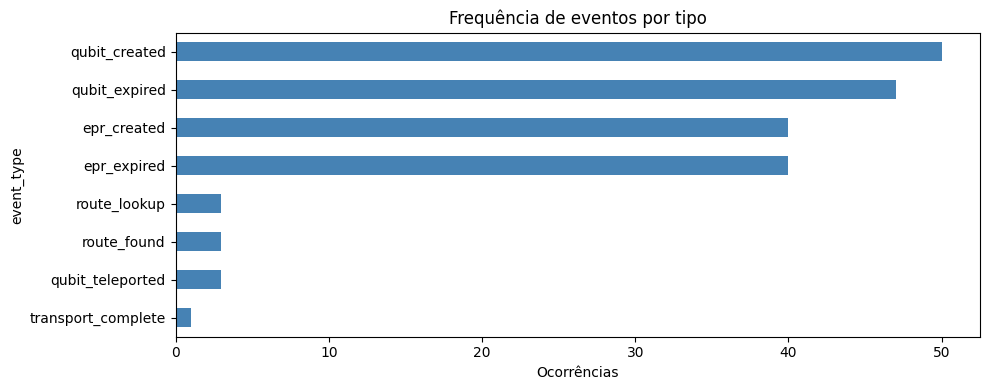

In [21]:
counts = df['event_type'].value_counts()

fig, ax = plt.subplots(figsize=(10, 4))
counts.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Frequência de eventos por tipo')
ax.set_xlabel('Ocorrências')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### 6.4 Coleta durante protocolo QKD E91

In [22]:
csv_qkd = os.path.join(tempfile.gettempdir(), 'quantumnet_qkd.csv')

clock = Clock()
net   = Network(clock=clock)

with MetricsCollector(clock, csv_qkd):
    net.set_ready_topology('Line', 3)
    net.application_layer.run_app('QKD_E91', 0, 2, 8)
    clock.run()

df_qkd = pd.read_csv(csv_qkd)
print(f"Total de eventos QKD: {len(df_qkd)}")
print(f"Duração total: {df_qkd['clock_tick'].max()} timeslots\n")

# Resumo por tipo
display(df_qkd.groupby('event_type').size().rename('ocorrências').reset_index())

Total de eventos QKD: 115
Duração total: 25 timeslots



,event_type,ocorrências
0,e91_failed,1
1,e91_qubits_prepared,1
2,epr_created,20
3,epr_expired,20
4,qubit_created,36
5,qubit_expired,36
6,transport_failed,1


---
## 7. Controlador (`Controller`) — Tabelas de Roteamento

O `Controller` pré-computa tabelas de roteamento shortest-path para todos os hosts usando NetworkX.

In [23]:
clock = Clock()
net   = Network(clock=clock)
net.set_ready_topology('Grid', 3, 3)

controller = Controller(net)
controller.register_routing_tables()

# Tabela de roteamento do host 0 (canto superior esquerdo)
table = net.get_host(0).routing_table
print("Tabela de roteamento do host 0 (Grid 3×3):")
for dest, path in sorted(table.items()):
    print(f"  → host {dest}: {path}")

Tabela de roteamento do host 0 (Grid 3×3):
  → host 0: [0]
  → host 1: [0, 1]
  → host 2: [0, 1, 2]
  → host 3: [0, 3]
  → host 4: [0, 3, 4]
  → host 5: [0, 3, 4, 5]
  → host 6: [0, 3, 6]
  → host 7: [0, 3, 6, 7]
  → host 8: [0, 3, 6, 7, 8]
